In [1]:
import pickle
import awkward as ak
import numpy as np
import vector
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
truth_file="results/data_combined_test_seed_42.pkl"
corrected_file="results/H-HAN_mu60_10k_events_test_results.pkl"

In [3]:
with open(truth_file,"rb") as f:
    data = pickle.load(f)
    trks = data[2]

In [4]:
with open(corrected_file,"rb") as f:
    data = pickle.load(f)
    jets = data["jets"]
    jet_trk_IDs = data["jet_trk_IDs"]
mask = (jets[:,:,4]>0.1)&(jets[:,:,5]>0.1)
jets=jets[mask]
jet_trk_IDs=jet_trk_IDs[mask]

In [5]:
top_uncorrected = []
top_true_corrected = []
top_pred_corrected = []

# Loop over event
num_events=len(jets)
for event in tqdm(range(num_events)):
    # Loop over jets in the event
    num_jets = len(jets[event])
    jet_num_fromBottom = []
    jet_num_fromW = []
    jet_num_total=[]
    jet_pt=[]
    for jet in range(num_jets):
        num_trks = len(jet_trk_IDs[event][jet])
        num_total=0
        num_fromBottom=0
        num_fromW=0
        for trk in range(num_trks):
            ID = jet_trk_IDs[event][jet][trk]
            arg = np.ravel(np.argwhere(trks[event]==ID))[0]
            if trks[event][arg][0]<1:
                continue
            num_total+=1
            fromBottom = trks[event][arg][6]
            fromW = trks[event][arg][7]
            if fromBottom==1:
                num_fromBottom+=1
            if fromW==1:
                num_fromW+=1
            #print(ID, arg, trks[event][arg])
        jet_num_fromBottom.append(num_fromBottom)
        jet_num_fromW.append(num_fromW)
        jet_pt.append(float(jets[event][jet][0]))
        jet_num_total.append(num_total)
    #print(jet_num_fromBottom)
    #print(jet_num_fromW)
    #print(jet_num_total)
    #print(jet_pt)
    sorted_jet_num_fromBottom = np.argsort(jet_num_fromBottom)
    sorted_jet_num_fromW = np.argsort(jet_num_fromW)
    #print(sorted_jet_num_fromBottom)
    #print(sorted_jet_num_fromW)
    b_arg = sorted_jet_num_fromBottom[-1]
    W1_arg = sorted_jet_num_fromW[-1]
    W2_arg = sorted_jet_num_fromW[-2]
    if (b_arg==W1_arg) or (b_arg==W2_arg):
        continue
    b_jet = jets[event][b_arg]
    W1_jet = jets[event][W1_arg]
    W2_jet = jets[event][W2_arg]

    b_jet = vector.obj(pt=b_jet[0],eta=b_jet[1],phi=b_jet[2],m=b_jet[3])
    W1_jet = vector.obj(pt=W1_jet[0],eta=W1_jet[1],phi=W1_jet[2],m=W1_jet[3])
    W2_jet = vector.obj(pt=W2_jet[0],eta=W2_jet[1],phi=W2_jet[2],m=W2_jet[3])

    uncorrected_jet_list = [b_jet, W1_jet, W2_jet]
    efrac_true_list = [jets[event][b_arg][4], jets[event][W1_arg][4], jets[event][W2_arg][4]]
    mfrac_true_list = [jets[event][b_arg][5], jets[event][W1_arg][5], jets[event][W2_arg][5]]
    efrac_pred_list = [jets[event][b_arg][6], jets[event][W1_arg][6], jets[event][W2_arg][6]]
    mfrac_pred_list = [jets[event][b_arg][7], jets[event][W1_arg][7], jets[event][W2_arg][7]]
    
    true_corrected_jet_list = []
    pred_corrected_jet_list = []
    for i, jet in enumerate(uncorrected_jet_list):
        true_corrected_mass = jet.M*mfrac_true_list[i]
        pred_corrected_mass = jet.M*mfrac_pred_list[i]

        true_corrected_energy = jet.E*efrac_true_list[i]
        pred_corrected_energy = jet.E*efrac_pred_list[i]
        
        true_corrected_mag_p = np.sqrt(np.abs(np.square(true_corrected_energy)-np.square(true_corrected_mass)))
        true_corrected_pT = true_corrected_mag_p / np.cosh(jet.eta)

        pred_corrected_mag_p = np.sqrt(np.abs(np.square(pred_corrected_energy)-np.square(pred_corrected_mass)))
        pred_corrected_pT = pred_corrected_mag_p / np.cosh(jet.eta)

        true_corrected_jet = vector.obj(pt=true_corrected_pT,eta=jet.eta,phi=jet.phi,m=true_corrected_mass)
        pred_corrected_jet = vector.obj(pt=pred_corrected_pT,eta=jet.eta,phi=jet.phi,m=pred_corrected_mass)

        true_corrected_jet_list.append(true_corrected_jet)
        pred_corrected_jet_list.append(pred_corrected_jet)

    uncorrected_top_quark = sum(uncorrected_jet_list, start=vector.MomentumObject4D(px=0, py=0, pz=0, E=0))
    true_corrected_top_quark = sum(true_corrected_jet_list, start=vector.MomentumObject4D(px=0, py=0, pz=0, E=0))
    pred_corrected_top_quark = sum(pred_corrected_jet_list, start=vector.MomentumObject4D(px=0, py=0, pz=0, E=0))

    top_uncorrected.append(uncorrected_top_quark.m)
    top_true_corrected.append(true_corrected_top_quark.m)
    top_pred_corrected.append(pred_corrected_top_quark.m)

100%|██████████| 1000/1000 [04:25<00:00,  3.76it/s]


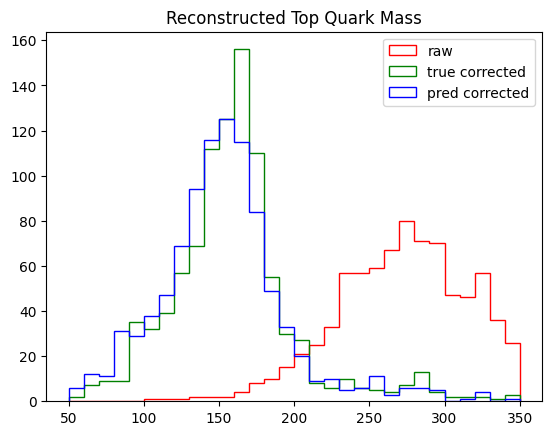

Top Mass Uncorrected:		Mean:  309.52  STD:  133.57
Top Mass True Corrected:	Mean:  168.57  STD:  93.87
Top Mass Pred Corrected:	Mean:  160.68  STD:  89.54


In [6]:
plt.title("Reconstructed Top Quark Mass")
plt.hist(top_uncorrected,range=(50,350),bins=30,histtype='step',color='r',label='raw')
plt.hist(top_true_corrected,range=(50,350),bins=30,histtype='step',color='g',label='true corrected')
plt.hist(top_pred_corrected,range=(50,350),bins=30,histtype='step',color='b',label='pred corrected')
plt.legend()
plt.show()

print("Top Mass Uncorrected:\t\tMean: ", round(np.mean(top_uncorrected),2)," STD: ", round(np.std(top_uncorrected),2))
print("Top Mass True Corrected:\tMean: ", round(np.mean(top_true_corrected),2)," STD: ", round(np.std(top_true_corrected),2))
print("Top Mass Pred Corrected:\tMean: ", round(np.mean(top_pred_corrected),2)," STD: ", round(np.std(top_pred_corrected),2))